# 01 — Exploratory Data Analysis
**AI Cost Optimization Portfolio**

Explores the synthetic cloud billing dataset.
---

In [1]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
plt.rcParams.update({'figure.dpi':120,'figure.figsize':(12,5),'axes.titlesize':14,'axes.titleweight':'bold'})
USD = mticker.FuncFormatter(lambda x,_: f'${x:,.0f}')
print('Libraries loaded OK')

Libraries loaded OK


## 1 - Load Data

In [2]:
DATA_PATH = Path('../data/raw/billing_data.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Not found: {DATA_PATH}. Run synth_generator.py first.')
df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])
print(f'Loaded {len(df):,} rows x {df.shape[1]} columns')
df.head()

Loaded 50,000 rows x 11 columns


,record_id,timestamp,account_id,team,service,region,resource_type,usage_hours,unit_cost,total_cost,anomaly_flag
0,c1db1e5c-3853-47bc-9a4c-2779e06bfbfc,2026-03-05 03:51:45.594822+00:00,acct-3edd62ca,ml-infra,Network,ap-southeast-1,load-balancer,2.79,0.4846,1.3520,False
1,15c64bd2-0703-4487-931c-adfff986d722,2026-03-05 03:55:38.779566+00:00,acct-45635401,finops,Storage,ap-northeast-1,cold-archive,46.48,0.0583,2.7098,False
2,7921870f-c393-486d-a848-c2ea8bbc6c8b,2026-03-05 03:56:12.643259+00:00,acct-77cfcabe,frontend,Serverless,ap-northeast-1,api-gateway,28.02,0.1982,5.5536,False
3,a7d80de3-fd28-445e-b439-d3980e7a4403,2026-03-05 03:56:28.609766+00:00,acct-3e814de5,data-engineering,Analytics,ap-southeast-1,data-factory,38.80,1.2047,46.7424,False
4,05c006ef-9f75-44f2-b8f3-8eb283289f2f,2026-03-05 04:08:37.595773+00:00,acct-c190d4e2,platform-eng,Serverless,ap-southeast-1,cloud-run,5.33,0.1357,0.7233,False


## 2 - Dataset Overview

In [3]:
print('=== dtypes ==='); print(df.dtypes,'\n')
print('=== missing values ==='); print(df.isnull().sum(),'\n')
print('=== numeric summary ==='); df.describe().round(2)

=== dtypes ===
record_id                        str
timestamp        datetime64[us, UTC]
account_id                       str
team                             str
service                          str
region                           str
resource_type                    str
usage_hours                  float64
unit_cost                    float64
total_cost                   float64
anomaly_flag                    bool
dtype: object 

=== missing values ===
record_id        0
timestamp        0
account_id       0
team             0
service          0
region           0
resource_type    0
usage_hours      0
unit_cost        0
total_cost       0
anomaly_flag     0
dtype: int64 

=== numeric summary ===


,usage_hours,unit_cost,total_cost
count,50000.00,50000.00,50000.00
mean,24.94,1.35,43.99
std,44.34,1.69,196.84
min,0.06,0.00,0.00
25%,5.40,0.13,1.36
50%,12.21,0.53,6.84
75%,27.45,2.08,29.48
max,2630.43,8.00,14329.81


In [4]:
print(f"Date range : {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
print(f"Services   : {sorted(df['service'].unique())}")
print(f"Teams      : {sorted(df['team'].unique())}")
n_anom = df['anomaly_flag'].sum()
anom_spend = df.loc[df['anomaly_flag'],'total_cost'].sum()
print(f'Total rows : {len(df):,}')
print(f'Anomalies  : {n_anom:,}  ({100*n_anom/len(df):.2f}%)')
print(f'Total spend: ${df["total_cost"].sum():,.2f}')
print(f'Anom spend : ${anom_spend:,.2f}  ({100*anom_spend/df["total_cost"].sum():.1f}% of total)')

Date range : 2026-03-05 to 2026-06-03
Services   : ['Analytics', 'Compute', 'Database', 'ML', 'Network', 'Serverless', 'Storage']
Teams      : ['backend-services', 'data-engineering', 'finops', 'frontend', 'ml-infra', 'platform-eng', 'research', 'security']
Total rows : 50,000
Anomalies  : 1,554  (3.11%)
Total spend: $2,199,288.25
Anom spend : $555,150.98  (25.2% of total)


## 3 - Cost Distribution

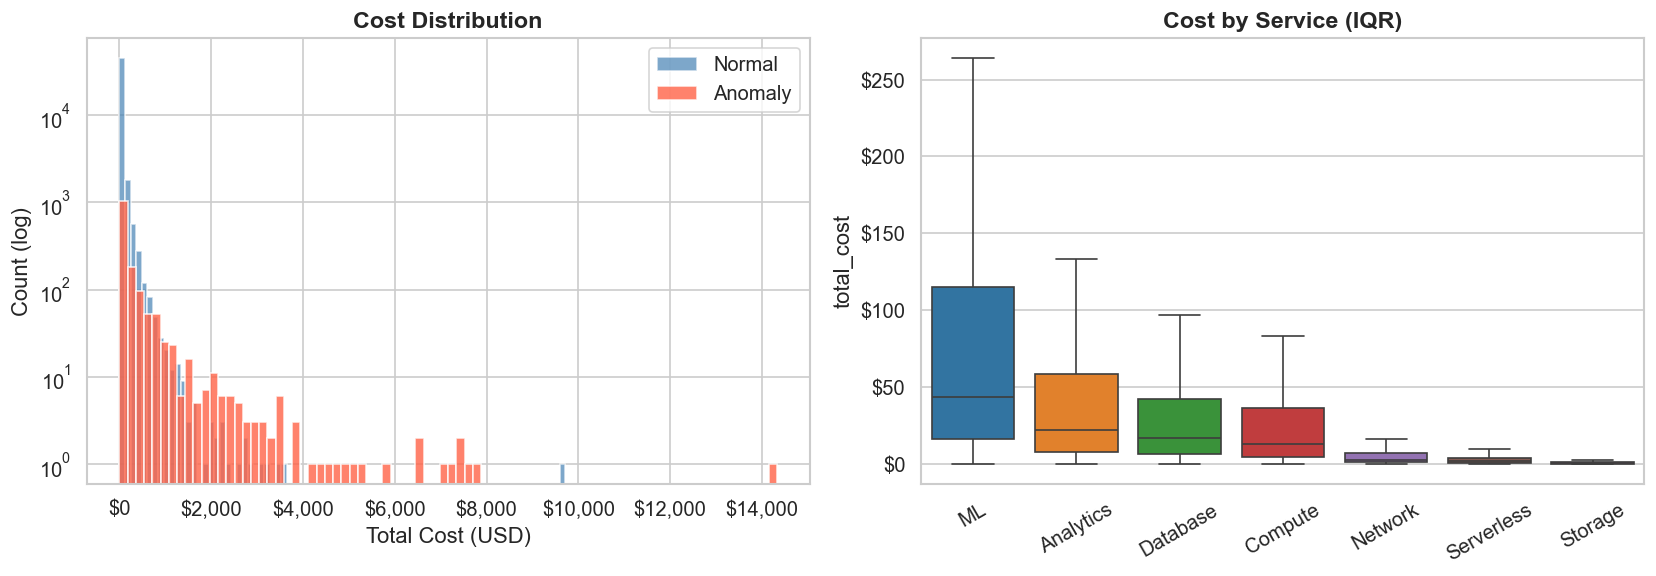

In [5]:
Path('../data/processed').mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(14,5))
ax = axes[0]
ax.hist(df.loc[~df['anomaly_flag'],'total_cost'], bins=80, color='steelblue', alpha=0.7, label='Normal', log=True)
ax.hist(df.loc[df['anomaly_flag'],'total_cost'],  bins=80, color='tomato',    alpha=0.8, label='Anomaly', log=True)
ax.set_xlabel('Total Cost (USD)'); ax.set_ylabel('Count (log)'); ax.set_title('Cost Distribution')
ax.legend(); ax.xaxis.set_major_formatter(USD)
ax = axes[1]
order = df.groupby('service')['total_cost'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='service', y='total_cost', order=order, palette='tab10', showfliers=False, ax=ax)
ax.set_title('Cost by Service (IQR)'); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(USD)
plt.tight_layout()
plt.savefig('../data/processed/cost_distribution.png', bbox_inches='tight'); plt.show()

## 4 - Spend by Service, Region and Team

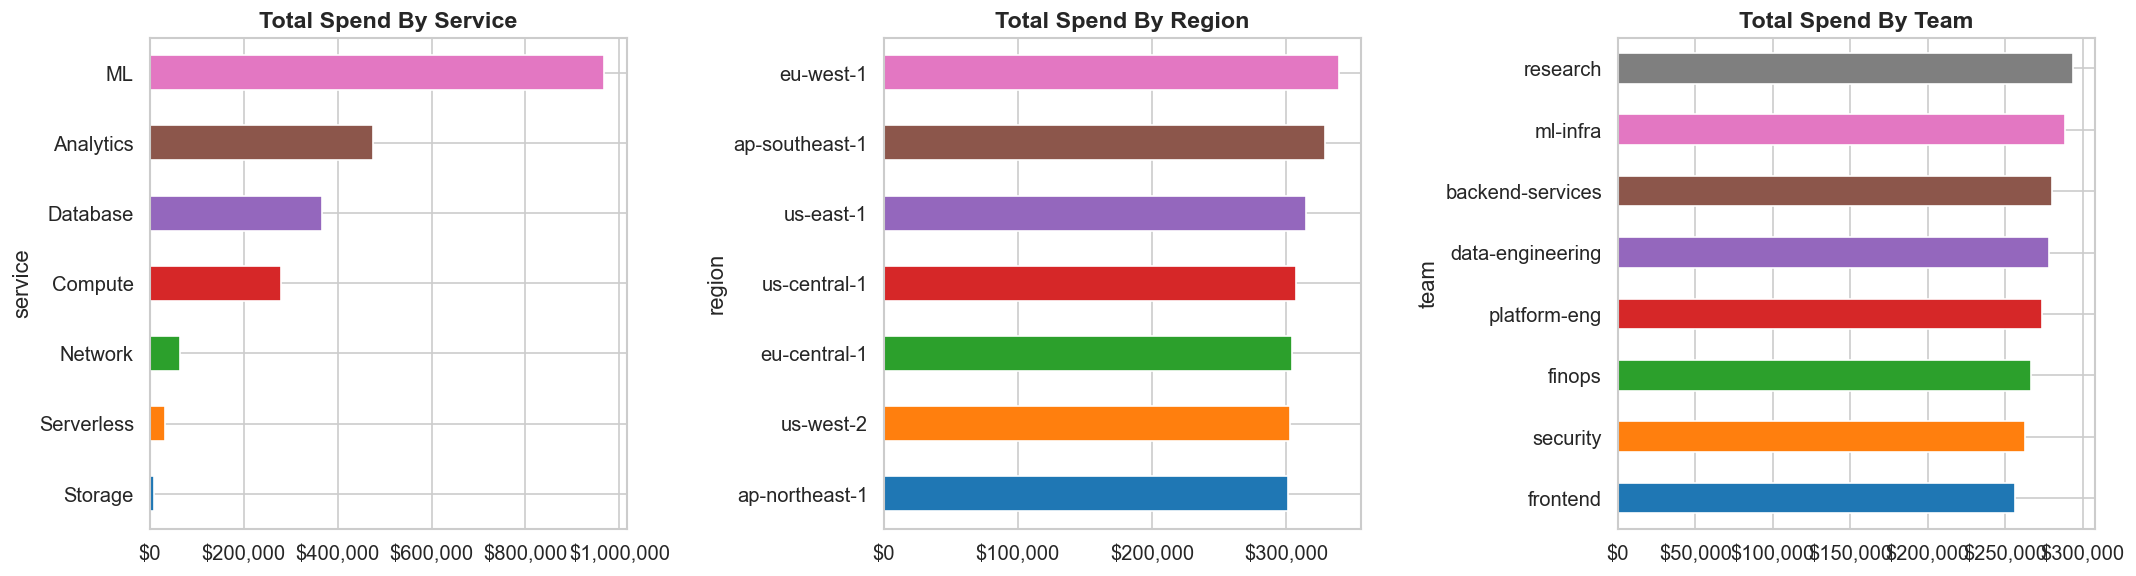

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for col, title, ax in [('service','By Service',axes[0]),('region','By Region',axes[1]),('team','By Team',axes[2])]:
    data = df.groupby(col)['total_cost'].sum().sort_values()
    data.plot(kind='barh', ax=ax, color=sns.color_palette('tab10', len(data)), edgecolor='white')
    ax.set_title(f'Total Spend {title}'); ax.xaxis.set_major_formatter(USD)
plt.tight_layout()
plt.savefig('../data/processed/spend_breakdown.png', bbox_inches='tight'); plt.show()

## 5 - Daily Spend Trends

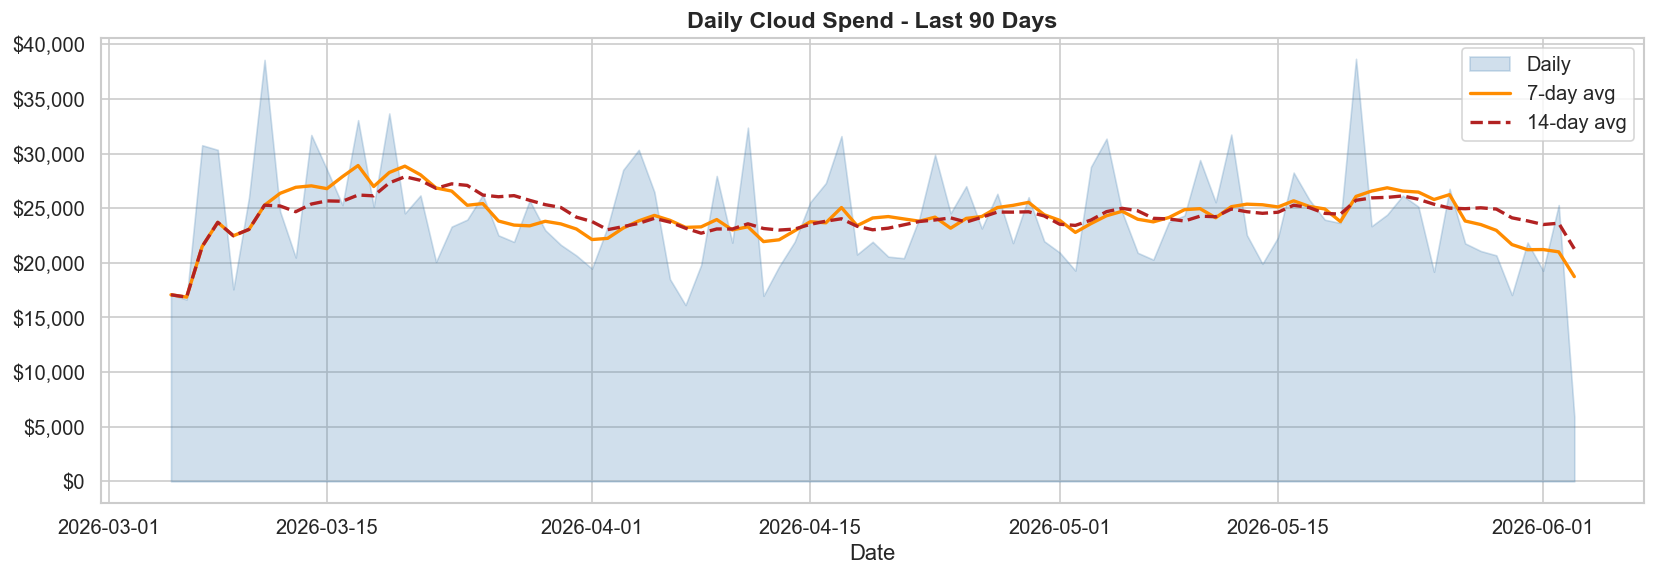

In [7]:
daily = df.set_index('timestamp').resample('D')['total_cost'].sum().to_frame('daily_cost')
daily['r7']  = daily['daily_cost'].rolling(7,  min_periods=1).mean()
daily['r14'] = daily['daily_cost'].rolling(14, min_periods=1).mean()
fig, ax = plt.subplots(figsize=(14,5))
ax.fill_between(daily.index, daily['daily_cost'], alpha=0.25, color='steelblue', label='Daily')
ax.plot(daily.index, daily['r7'],  color='darkorange', lw=2, label='7-day avg')
ax.plot(daily.index, daily['r14'], color='firebrick',  lw=2, label='14-day avg', ls='--')
ax.set_title('Daily Cloud Spend - Last 90 Days'); ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(USD); ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/daily_trend.png', bbox_inches='tight'); plt.show()

## 6 - Anomaly Profile

,total_records,anomaly_count,total_cost,anomaly_cost,anomaly_rate_pct,anomaly_cost_pct
service,,,,,,
Network,7093,236,64849.05,21326.22,3.33,32.89
Storage,7164,241,10133.32,3245.69,3.36,32.03
Database,7153,226,366694.90,104042.81,3.16,28.37
Analytics,7168,215,476401.22,119751.31,3.00,25.14
ML,7256,237,967985.48,233990.48,3.27,24.17
Compute,7016,197,280411.13,65680.30,2.81,23.42
Serverless,7150,202,32813.14,7114.18,2.83,21.68


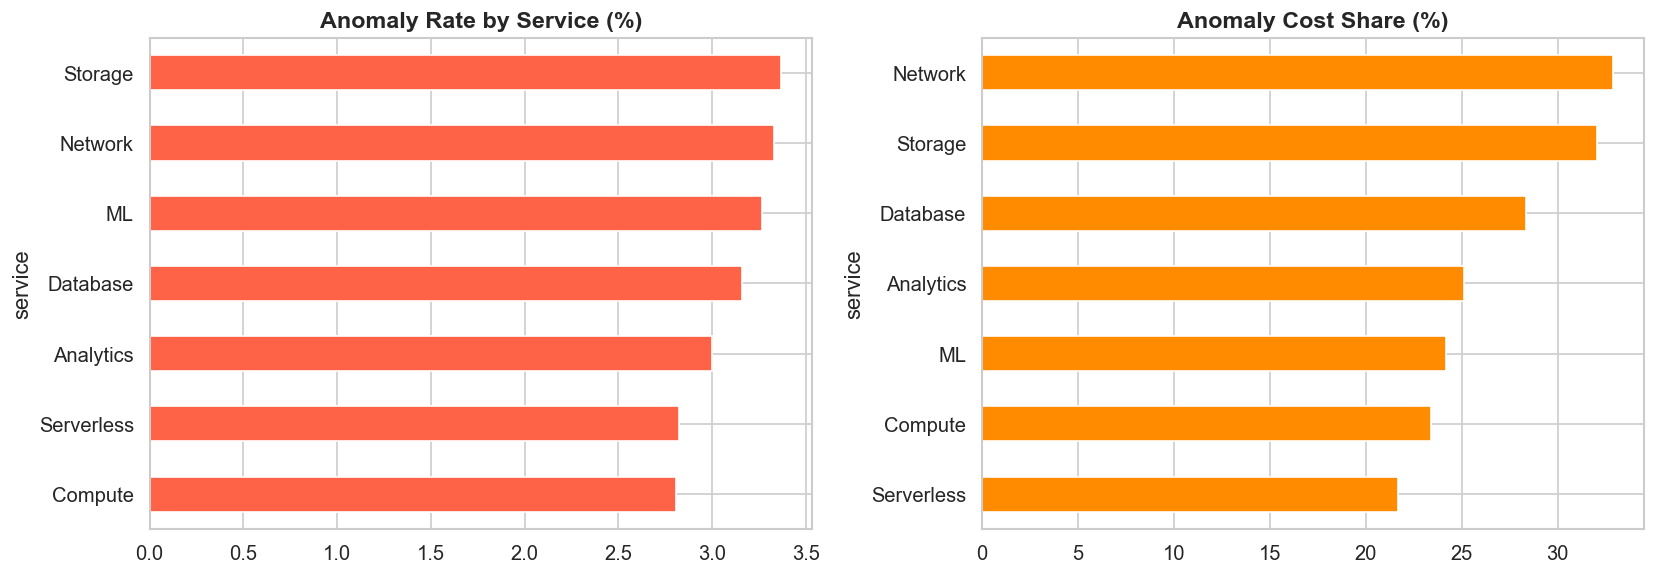

In [8]:
anom = df.groupby('service').agg(
    total_records=('record_id','count'),
    anomaly_count=('anomaly_flag','sum'),
    total_cost=('total_cost','sum'),
    anomaly_cost=('total_cost', lambda x: x[df.loc[x.index,'anomaly_flag']].sum()),
).assign(
    anomaly_rate_pct=lambda d: 100*d['anomaly_count']/d['total_records'],
    anomaly_cost_pct=lambda d: 100*d['anomaly_cost']/d['total_cost'],
).sort_values('anomaly_cost_pct', ascending=False)
display(anom.round(2))
fig, axes = plt.subplots(1, 2, figsize=(14,5))
anom['anomaly_rate_pct'].sort_values().plot(kind='barh', ax=axes[0], color='tomato', edgecolor='white')
axes[0].set_title('Anomaly Rate by Service (%)')
anom['anomaly_cost_pct'].sort_values().plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Anomaly Cost Share (%)')
plt.tight_layout()
plt.savefig('../data/processed/anomaly_profile.png', bbox_inches='tight'); plt.show()

## 7 - Correlation Heatmap

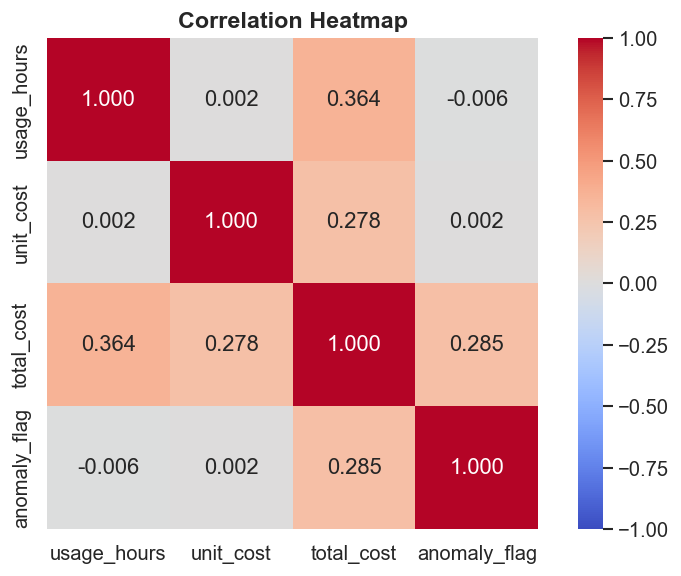

In [9]:
corr = df[['usage_hours','unit_cost','total_cost','anomaly_flag']].corr()
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png', bbox_inches='tight'); plt.show()

## 8 - Top-10 Cost Drivers

,rank,team,service,resource_type,cost_fmt
0,1,research,ML,training-job,"$48,015.59"
1,2,ml-infra,ML,notebook-instance,"$42,789.57"
2,3,platform-eng,ML,training-job,"$40,853.02"
3,4,finops,ML,training-job,"$38,103.83"
4,5,backend-services,ML,feature-store,"$35,637.30"
5,6,security,ML,notebook-instance,"$35,562.01"
6,7,data-engineering,ML,training-job,"$34,957.78"
7,8,research,ML,inference-endpoint,"$34,414.93"
8,9,backend-services,ML,notebook-instance,"$34,366.45"
9,10,frontend,ML,training-job,"$34,254.30"


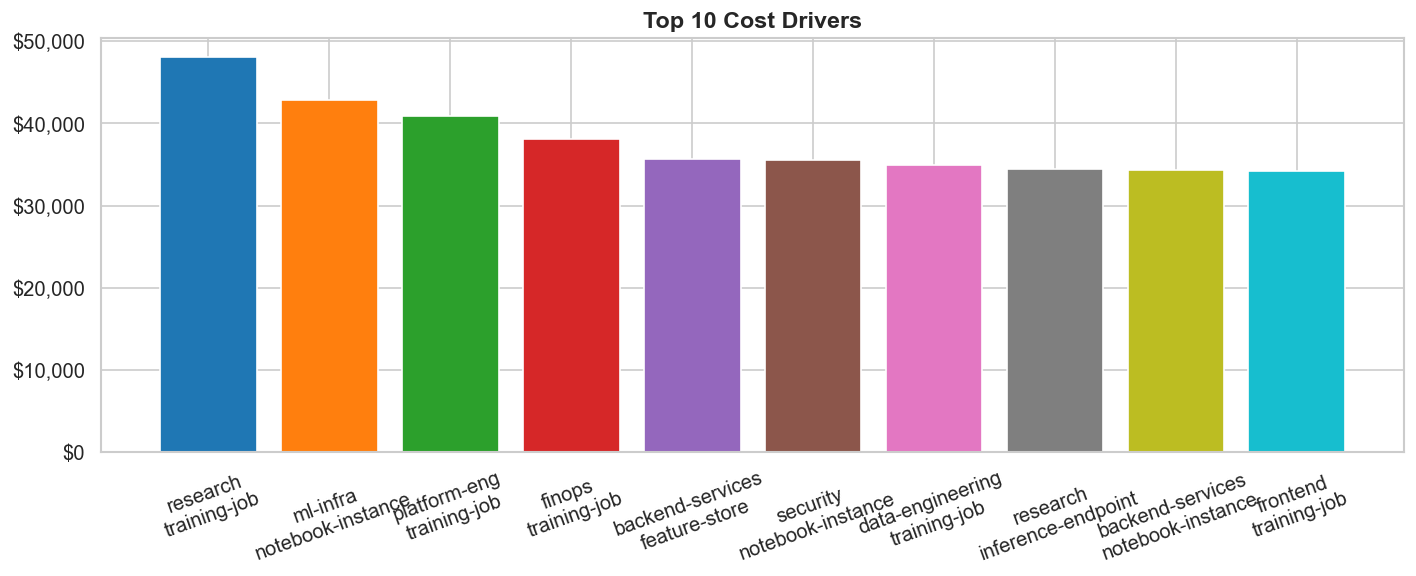

In [10]:
top = df.groupby(['team','service','resource_type'])['total_cost'].sum()\
        .reset_index().sort_values('total_cost', ascending=False).head(10).reset_index(drop=True)
top['rank'] = top.index + 1
top['cost_fmt'] = top['total_cost'].apply(lambda x: f'${x:,.2f}')
display(top[['rank','team','service','resource_type','cost_fmt']])
fig, ax = plt.subplots(figsize=(12,5))
labels = top.apply(lambda r: r['team']+'\n'+r['resource_type'], axis=1)
bars = ax.bar(labels, top['total_cost'], color=sns.color_palette('tab10',10), edgecolor='white')
ax.set_title('Top 10 Cost Drivers'); ax.yaxis.set_major_formatter(USD)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('../data/processed/top10_cost_drivers.png', bbox_inches='tight'); plt.show()

## 9 - Save EDA Summary

In [11]:
summary = df.groupby(['service','team','region']).agg(
    records=('record_id','count'), total_cost=('total_cost','sum'),
    mean_cost=('total_cost','mean'), anomalies=('anomaly_flag','sum')
).reset_index()
out = Path('../data/processed/eda_summary.csv')
out.parent.mkdir(parents=True, exist_ok=True)
summary.to_csv(out, index=False)
print(f'Saved EDA summary --> {out.resolve()}')
print(f'Shape: {summary.shape}')
summary.head(10)

Saved EDA summary --> /Users/bbkar/ai-cost-optimization-portfolio/data/processed/eda_summary.csv
Shape: (392, 7)


,service,team,region,records,total_cost,mean_cost,anomalies
0,Analytics,backend-services,ap-northeast-1,125,7677.9698,61.423758,7
1,Analytics,backend-services,ap-southeast-1,125,8545.7121,68.365697,6
2,Analytics,backend-services,eu-central-1,150,7841.1009,52.274006,2
3,Analytics,backend-services,eu-west-1,115,6686.5547,58.143954,3
4,Analytics,backend-services,us-central-1,119,8198.2900,68.893193,4
5,Analytics,backend-services,us-east-1,122,7650.6387,62.710153,5
6,Analytics,backend-services,us-west-2,143,14138.4715,98.870430,7
7,Analytics,data-engineering,ap-northeast-1,117,10133.0681,86.607420,3
8,Analytics,data-engineering,ap-southeast-1,118,6295.5262,53.351917,2
9,Analytics,data-engineering,eu-central-1,136,7005.4330,51.510537,5
